## 1. Import Libraries & Load Data

In [ ]:
import sys
from pathlib import Path

_here = Path.cwd()
PROJECT_ROOT = next(
    (p for p in [_here] + list(_here.parents) if (p / 'config.py').exists()),
    _here
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import PROJECT_ROOT, DATA_DIR, RAW_DIR, PROCESSED_DIR, SPLITS_DIR

MODELS_DIR    = PROJECT_ROOT / 'models'
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:

# Load data
train = pd.read_csv(PROCESSED_DIR / 'train_cleaned.csv', parse_dates=['date'])
stores = pd.read_csv(PROCESSED_DIR / 'stores_cleaned.csv')
print(f"Data shape: {train.shape}")
print(f"Date range: {train['date'].min()} to {train['date'].max()}")
print(f"Stores shape: {stores.shape}")

Data shape: (3000888, 6)
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Stores shape: (54, 6)


## 2. Data Preparation

In [4]:
# ==== DATA QUALITY CHECK ====
print("=== TRAIN DATA ===")
print(train.dtypes)
print(f"\nMissing values:\n{train.isnull().sum()}")
print(f"\nZero sales records: {(train['sales'] == 0).sum():,} ({(train['sales'] == 0).mean()*100:.2f}%)")

print("\n=== STORES DATA ===")
print(stores.dtypes)
print(f"\nMissing values:\n{stores.isnull().sum()}")
print(f"\nStore types: {sorted(stores['type'].unique())}")
print(f"Clusters: {sorted(stores['cluster'].unique())}")
print(f"Cities: {stores['city'].nunique()} unique")
print(f"States: {stores['state'].nunique()} unique")

=== TRAIN DATA ===
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Zero sales records: 939,130 (31.30%)

=== STORES DATA ===
store_nbr        int64
city            object
state           object
type            object
cluster          int64
type_encoded     int64
dtype: object

Missing values:
store_nbr       0
city            0
state           0
type            0
cluster         0
type_encoded    0
dtype: int64

Store types: ['A', 'B', 'C', 'D', 'E']
Clusters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
Cities: 22 unique
States: 

In [5]:
# ==== MERGE TRAIN + STORES ====
df = train.merge(stores, on='store_nbr', how='left')
print(f"Merged shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Merged shape: (3000888, 11)
Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'type_encoded']


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,type_encoded
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,3
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,3
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,3
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,3
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,3


In [6]:
# ==== AGGREGATE SALES BY STORE ====
store_metrics = df.groupby('store_nbr').agg(
    total_sales=('sales', 'sum'),
    avg_daily_sales=('sales', 'mean'),
    median_daily_sales=('sales', 'median'),
    std_daily_sales=('sales', 'std'),
    max_daily_sales=('sales', 'max'),
    zero_sales_count=('sales', lambda x: (x == 0).sum()),
    total_records=('sales', 'count')
).reset_index()

# Calculate derived metrics
store_metrics['cv'] = store_metrics['std_daily_sales'] / store_metrics['avg_daily_sales']  # Coefficient of Variation
store_metrics['zero_sales_pct'] = store_metrics['zero_sales_count'] / store_metrics['total_records'] * 100

# Merge with store metadata
store_metrics = store_metrics.merge(stores, on='store_nbr', how='left')

# Rank stores
store_metrics['rank_total'] = store_metrics['total_sales'].rank(ascending=False).astype(int)
store_metrics = store_metrics.sort_values('total_sales', ascending=False)

print(f"Store metrics calculated for {len(store_metrics)} stores")
print(f"\nTop 5 stores by total sales:")
print(store_metrics[['store_nbr', 'city', 'state', 'type', 'cluster', 'total_sales', 'avg_daily_sales', 'cv', 'zero_sales_pct']].head())
print(f"\nBottom 5 stores by total sales:")
print(store_metrics[['store_nbr', 'city', 'state', 'type', 'cluster', 'total_sales', 'avg_daily_sales', 'cv', 'zero_sales_pct']].tail())

Store metrics calculated for 54 stores

Top 5 stores by total sales:
    store_nbr   city      state type  cluster   total_sales  avg_daily_sales  \
43         44  Quito  Pichincha    A        5  6.208755e+07      1117.245254   
44         45  Quito  Pichincha    A       11  5.449801e+07       980.673908   
46         47  Quito  Pichincha    A       14  5.094831e+07       916.798209   
2           3  Quito  Pichincha    D        8  5.048191e+07       908.405495   
48         49  Quito  Pichincha    A       11  4.342010e+07       781.330450   

          cv  zero_sales_pct  
43  2.403485       17.947887  
44  2.431309       19.358670  
46  2.423998       18.953790  
2   2.362585       18.140430  
48  2.429013       19.347873  

Bottom 5 stores by total sales:
    store_nbr       city    state type  cluster   total_sales  \
34         35     Playas   Guayas    C        3  7.676679e+06   
29         30  Guayaquil   Guayas    C        3  7.382074e+06   
31         32  Guayaquil   Guayas   

In [7]:
# ==== SUMMARY STATISTICS ====
print("="*70)
print("STORE PERFORMANCE OVERVIEW")
print("="*70)

print(f"\nTotal stores: {len(store_metrics)}")
print(f"Total sales (all stores): ${store_metrics['total_sales'].sum():,.0f}")
print(f"Average total sales per store: ${store_metrics['total_sales'].mean():,.0f}")
print(f"Median total sales per store: ${store_metrics['total_sales'].median():,.0f}")

# Concentration
top5_share = store_metrics.head(5)['total_sales'].sum() / store_metrics['total_sales'].sum() * 100
top10_share = store_metrics.head(10)['total_sales'].sum() / store_metrics['total_sales'].sum() * 100
bottom10_share = store_metrics.tail(10)['total_sales'].sum() / store_metrics['total_sales'].sum() * 100

print(f"\nConcentration:")
print(f"  Top 5 stores: {top5_share:.1f}% of total sales")
print(f"  Top 10 stores: {top10_share:.1f}% of total sales")
print(f"  Bottom 10 stores: {bottom10_share:.1f}% of total sales")
print(f"  Max/Min ratio: {store_metrics['total_sales'].max() / store_metrics['total_sales'].min():.1f}x")

print(f"\nZero Sales Analysis:")
print(f"  Average zero-sales %: {store_metrics['zero_sales_pct'].mean():.1f}%")
print(f"  Max zero-sales %: {store_metrics['zero_sales_pct'].max():.1f}% (Store {store_metrics.loc[store_metrics['zero_sales_pct'].idxmax(), 'store_nbr']})")
print(f"  Min zero-sales %: {store_metrics['zero_sales_pct'].min():.1f}% (Store {store_metrics.loc[store_metrics['zero_sales_pct'].idxmin(), 'store_nbr']})")

STORE PERFORMANCE OVERVIEW

Total stores: 54
Total sales (all stores): $1,073,644,952
Average total sales per store: $19,882,314
Median total sales per store: $15,992,048

Concentration:
  Top 5 stores: 24.4% of total sales
  Top 10 stores: 40.2% of total sales
  Bottom 10 stores: 6.8% of total sales
  Max/Min ratio: 23.0x

Zero Sales Analysis:
  Average zero-sales %: 31.3%
  Max zero-sales %: 93.5% (Store 52)
  Min zero-sales %: 17.9% (Store 44)


## 3. Top 10 & Bottom 10 Stores by Total Sales

Nhận diện stores có performance cao nhất và thấp nhất.

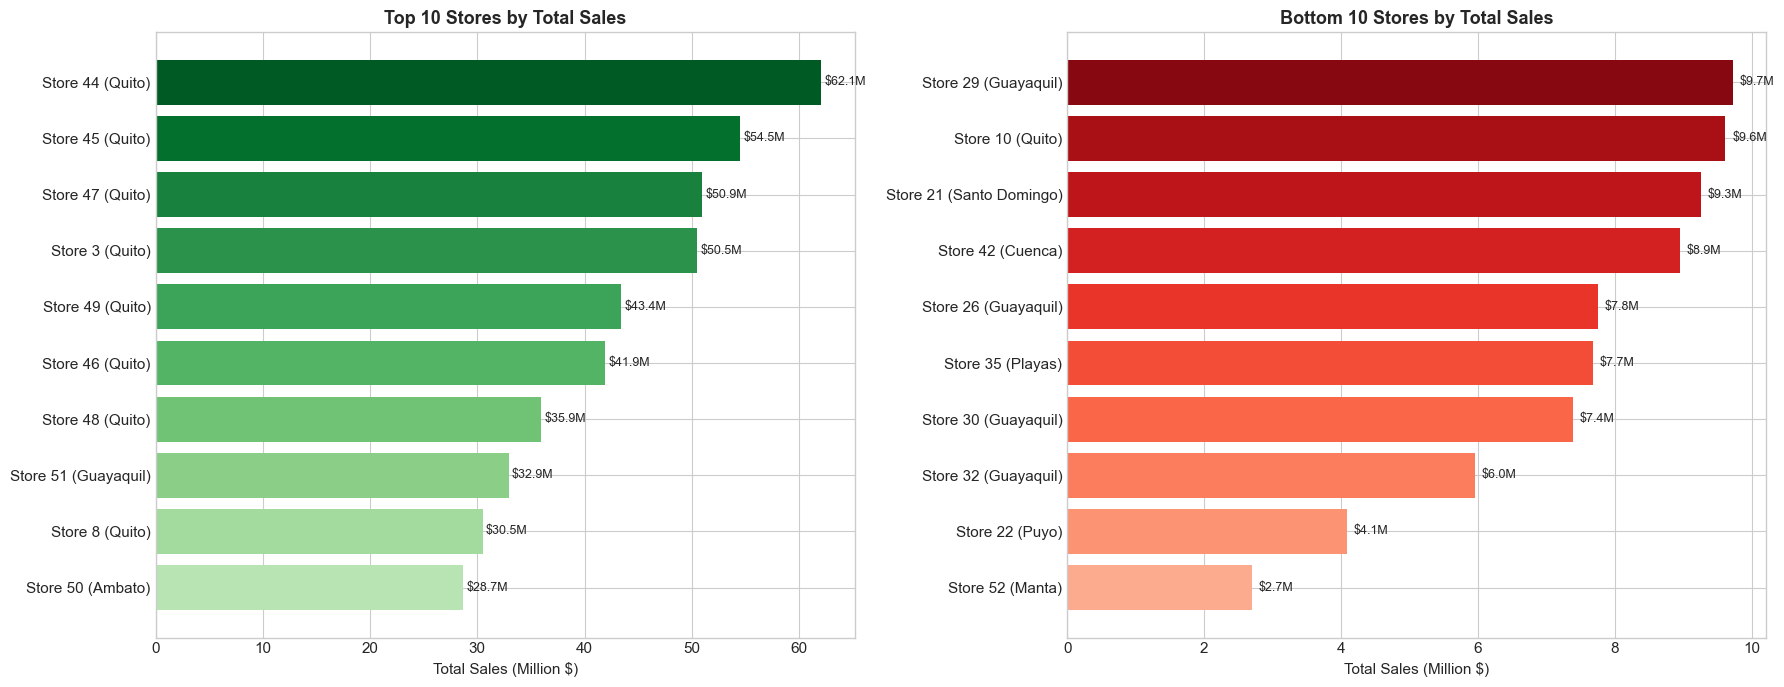


=== KEY INSIGHT ===
Best: Store 44 (Quito, Pichincha) - Type A, Cluster 5
Worst: Store 52 (Manta, Manabi) - Type A, Cluster 11
Difference: 23.0x


In [8]:
# ==== BAR CHART: TOP 10 & BOTTOM 10 STORES ====
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10
top10 = store_metrics.head(10).sort_values('total_sales', ascending=True)
colors_top = [plt.cm.Greens(0.3 + 0.07 * i) for i in range(10)]
bars1 = axes[0].barh(
    [f"Store {int(s)} ({c})" for s, c in zip(top10['store_nbr'], top10['city'])],
    top10['total_sales'] / 1e6,
    color=colors_top
)
axes[0].set_xlabel('Total Sales (Million $)')
axes[0].set_title('Top 10 Stores by Total Sales', fontweight='bold')
for bar, val in zip(bars1, top10['total_sales'] / 1e6):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'${val:.1f}M', va='center', fontsize=9)

# Bottom 10
bottom10 = store_metrics.tail(10).sort_values('total_sales', ascending=True)
colors_bot = [plt.cm.Reds(0.3 + 0.07 * i) for i in range(10)]
bars2 = axes[1].barh(
    [f"Store {int(s)} ({c})" for s, c in zip(bottom10['store_nbr'], bottom10['city'])],
    bottom10['total_sales'] / 1e6,
    color=colors_bot
)
axes[1].set_xlabel('Total Sales (Million $)')
axes[1].set_title('Bottom 10 Stores by Total Sales', fontweight='bold')
for bar, val in zip(bars2, bottom10['total_sales'] / 1e6):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'${val:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print comparison
print("\n=== KEY INSIGHT ===")
best = store_metrics.iloc[0]
worst = store_metrics.iloc[-1]
print(f"Best: Store {int(best['store_nbr'])} ({best['city']}, {best['state']}) - Type {best['type']}, Cluster {int(best['cluster'])}")
print(f"Worst: Store {int(worst['store_nbr'])} ({worst['city']}, {worst['state']}) - Type {worst['type']}, Cluster {int(worst['cluster'])}")
print(f"Difference: {best['total_sales']/worst['total_sales']:.1f}x")

## 4. Sales Distribution by Store Type (A, B, C, D, E)

Phân tích xem store type nào có sales cao nhất và có significant difference giữa các types không.

In [9]:
# ==== STORE TYPE ANALYSIS ====
# Count stores per type
type_counts = stores['type'].value_counts().sort_index()
print("Store count by type:")
print(type_counts)

# Type-level metrics
type_metrics = store_metrics.groupby('type').agg(
    num_stores=('store_nbr', 'count'),
    total_sales=('total_sales', 'sum'),
    avg_total_sales=('total_sales', 'mean'),
    median_total_sales=('total_sales', 'median'),
    avg_daily=('avg_daily_sales', 'mean'),
    avg_cv=('cv', 'mean'),
    avg_zero_pct=('zero_sales_pct', 'mean')
).round(2)

print("\nType-level metrics:")
print(type_metrics)

Store count by type:
type
A     9
B     8
C    15
D    18
E     4
Name: count, dtype: int64

Type-level metrics:
      num_stores   total_sales  avg_total_sales  median_total_sales  \
type                                                                  
A              9  3.530438e+08      39227093.53         41896062.12   
B              8  1.452606e+08      18157579.39         17418803.43   
C             15  1.644347e+08      10962316.17         10986412.55   
D             18  3.510833e+08      19504627.60         18884849.82   
E              4  5.982244e+07      14955608.96         15857061.65   

      avg_daily  avg_cv  avg_zero_pct  
type                                   
A        705.88    3.20         27.84  
B        326.74    2.99         33.30  
C        197.26    2.90         35.96  
D        350.98    2.54         26.68  
E        269.12    2.87         38.34  


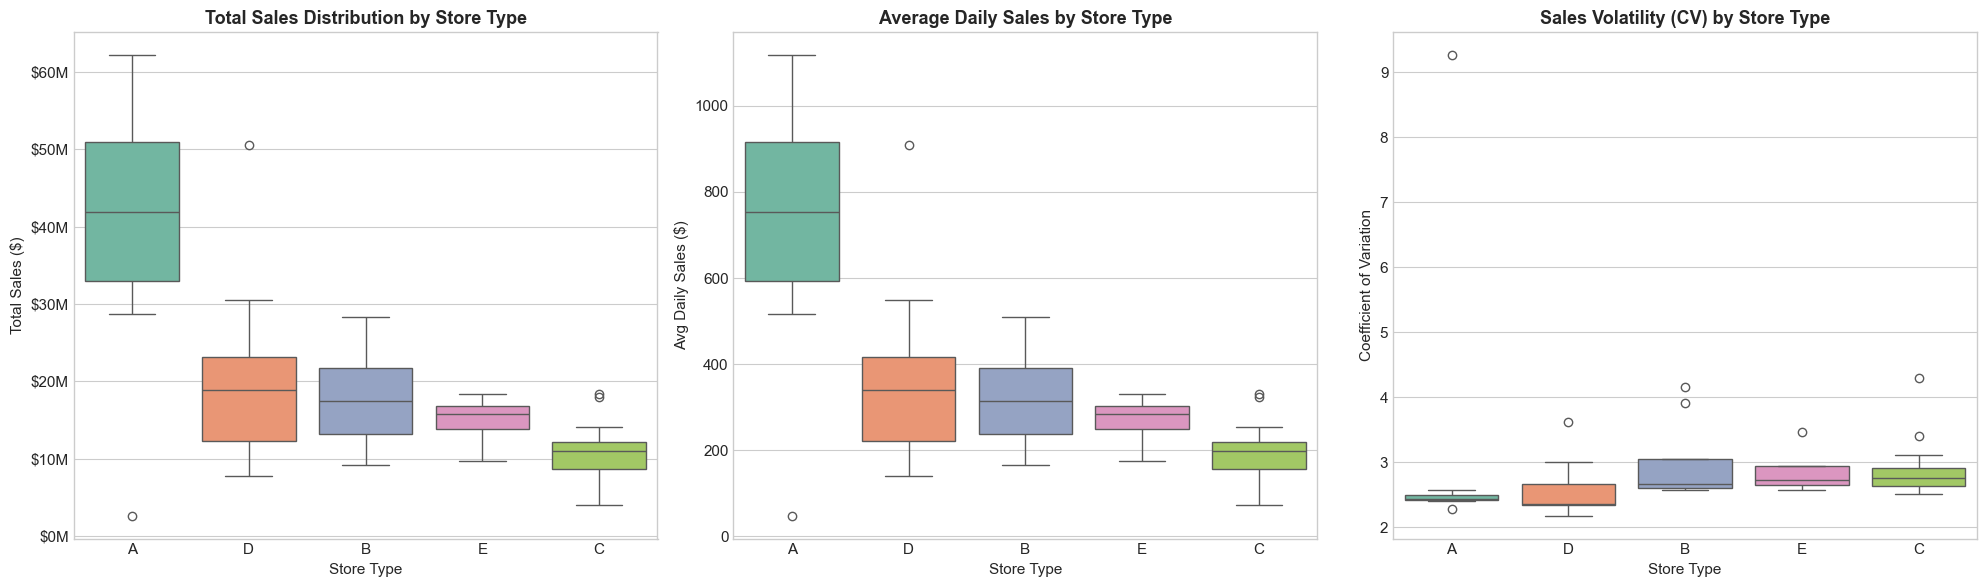

In [10]:
# ==== BOX PLOTS: SALES BY STORE TYPE ====
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (A) Box plot: Total sales by type
type_order = store_metrics.groupby('type')['total_sales'].median().sort_values(ascending=False).index
sns.boxplot(data=store_metrics, x='type', y='total_sales', order=type_order, ax=axes[0], palette='Set2')
axes[0].set_title('Total Sales Distribution by Store Type', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_xlabel('Store Type')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# (B) Box plot: Average daily sales by type
sns.boxplot(data=store_metrics, x='type', y='avg_daily_sales', order=type_order, ax=axes[1], palette='Set2')
axes[1].set_title('Average Daily Sales by Store Type', fontweight='bold')
axes[1].set_ylabel('Avg Daily Sales ($)')
axes[1].set_xlabel('Store Type')

# (C) Box plot: CV (stability) by type
sns.boxplot(data=store_metrics, x='type', y='cv', order=type_order, ax=axes[2], palette='Set2')
axes[2].set_title('Sales Volatility (CV) by Store Type', fontweight='bold')
axes[2].set_ylabel('Coefficient of Variation')
axes[2].set_xlabel('Store Type')

plt.tight_layout()
plt.show()

In [11]:
# ==== STATISTICAL TEST: Kruskal-Wallis (Non-parametric ANOVA) ====
# Test if there's significant difference between store types
groups = [group['total_sales'].values for name, group in store_metrics.groupby('type')]
h_stat, p_value = stats.kruskal(*groups)

print("=== Kruskal-Wallis Test: Sales ~ Store Type ===")
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("=> SIGNIFICANT difference between store types (p < 0.05)")
else:
    print("=> NO significant difference between store types (p >= 0.05)")

# Pairwise comparisons (Mann-Whitney U)
print("\n=== Pairwise Mann-Whitney U Tests ===")
types = sorted(store_metrics['type'].unique())
for i in range(len(types)):
    for j in range(i+1, len(types)):
        g1 = store_metrics[store_metrics['type'] == types[i]]['total_sales']
        g2 = store_metrics[store_metrics['type'] == types[j]]['total_sales']
        u_stat, p_val = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"  {types[i]} vs {types[j]}: U={u_stat:.0f}, p={p_val:.4f} {sig}")

=== Kruskal-Wallis Test: Sales ~ Store Type ===
H-statistic: 21.4630
P-value: 0.000256
=> SIGNIFICANT difference between store types (p < 0.05)

=== Pairwise Mann-Whitney U Tests ===
  A vs B: U=64, p=0.0055 **
  A vs C: U=120, p=0.0019 **
  A vs D: U=138, p=0.0037 **
  A vs E: U=32, p=0.0336 *
  B vs C: U=98, p=0.0130 *
  B vs D: U=71, p=0.9783 ns
  B vs E: U=20, p=0.5697 ns
  C vs D: U=44, p=0.0011 **
  C vs E: U=15, p=0.1522 ns
  D vs E: U=47, p=0.3863 ns


## 9. Zero-Sales Deep Dive

Identify stores with unusually high zero-sales rates.


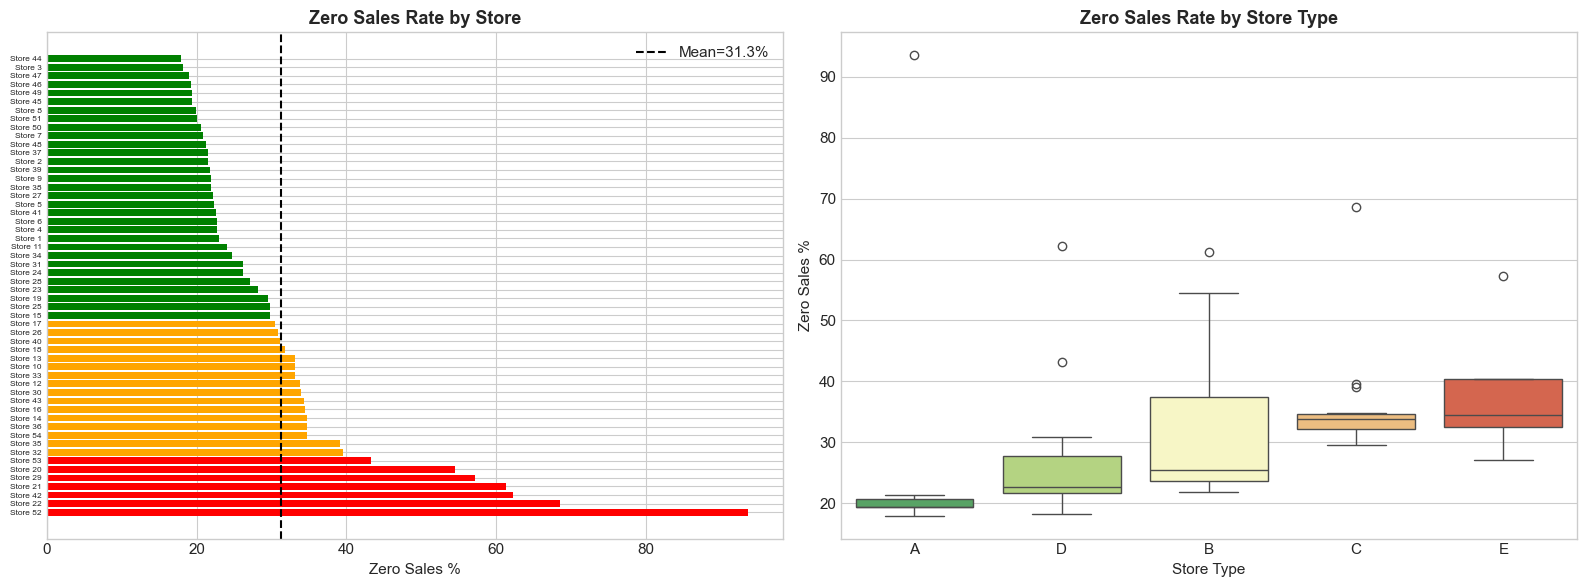

=== Stores with Highest Zero-Sales Rates ===
  Store 52: 93.5% zero sales (Manta, Type A, Cluster 11)
  Store 22: 68.5% zero sales (Puyo, Type C, Cluster 7)
  Store 42: 62.2% zero sales (Cuenca, Type D, Cluster 2)
  Store 21: 61.3% zero sales (Santo Domingo, Type B, Cluster 6)
  Store 29: 57.2% zero sales (Guayaquil, Type E, Cluster 10)


In [12]:
# ==== ZERO SALES DEEP DIVE ====
# Which stores have unusually high zero-sales rates?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (A) Zero sales % by store (sorted)
zero_sorted = store_metrics.sort_values('zero_sales_pct', ascending=False)
colors_zero = ['red' if z > 40 else 'orange' if z > 30 else 'green'
               for z in zero_sorted['zero_sales_pct']]
axes[0].barh(
    [f"Store {int(s)}" for s in zero_sorted['store_nbr']],
    zero_sorted['zero_sales_pct'],
    color=colors_zero
)
axes[0].set_xlabel('Zero Sales %')
axes[0].set_title('Zero Sales Rate by Store', fontweight='bold')
axes[0].axvline(x=store_metrics['zero_sales_pct'].mean(), color='black', linestyle='--',
                label=f"Mean={store_metrics['zero_sales_pct'].mean():.1f}%")
axes[0].legend()
axes[0].tick_params(axis='y', labelsize=6)

# (B) Zero sales % by store type
sns.boxplot(data=store_metrics, x='type', y='zero_sales_pct', ax=axes[1], palette='RdYlGn_r')
axes[1].set_title('Zero Sales Rate by Store Type', fontweight='bold')
axes[1].set_ylabel('Zero Sales %')
axes[1].set_xlabel('Store Type')

plt.tight_layout()
plt.show()

# Print stores with highest zero-sales rates
print("=== Stores with Highest Zero-Sales Rates ===")
high_zero = store_metrics.nlargest(5, 'zero_sales_pct')
for _, row in high_zero.iterrows():
    print(f"  Store {int(row['store_nbr'])}: {row['zero_sales_pct']:.1f}% zero sales "
          f"({row['city']}, Type {row['type']}, Cluster {int(row['cluster'])})")

## 10. Product Family Performance by Store Type

Phân tích xem các store types khác nhau có bán các product families khác nhau không.

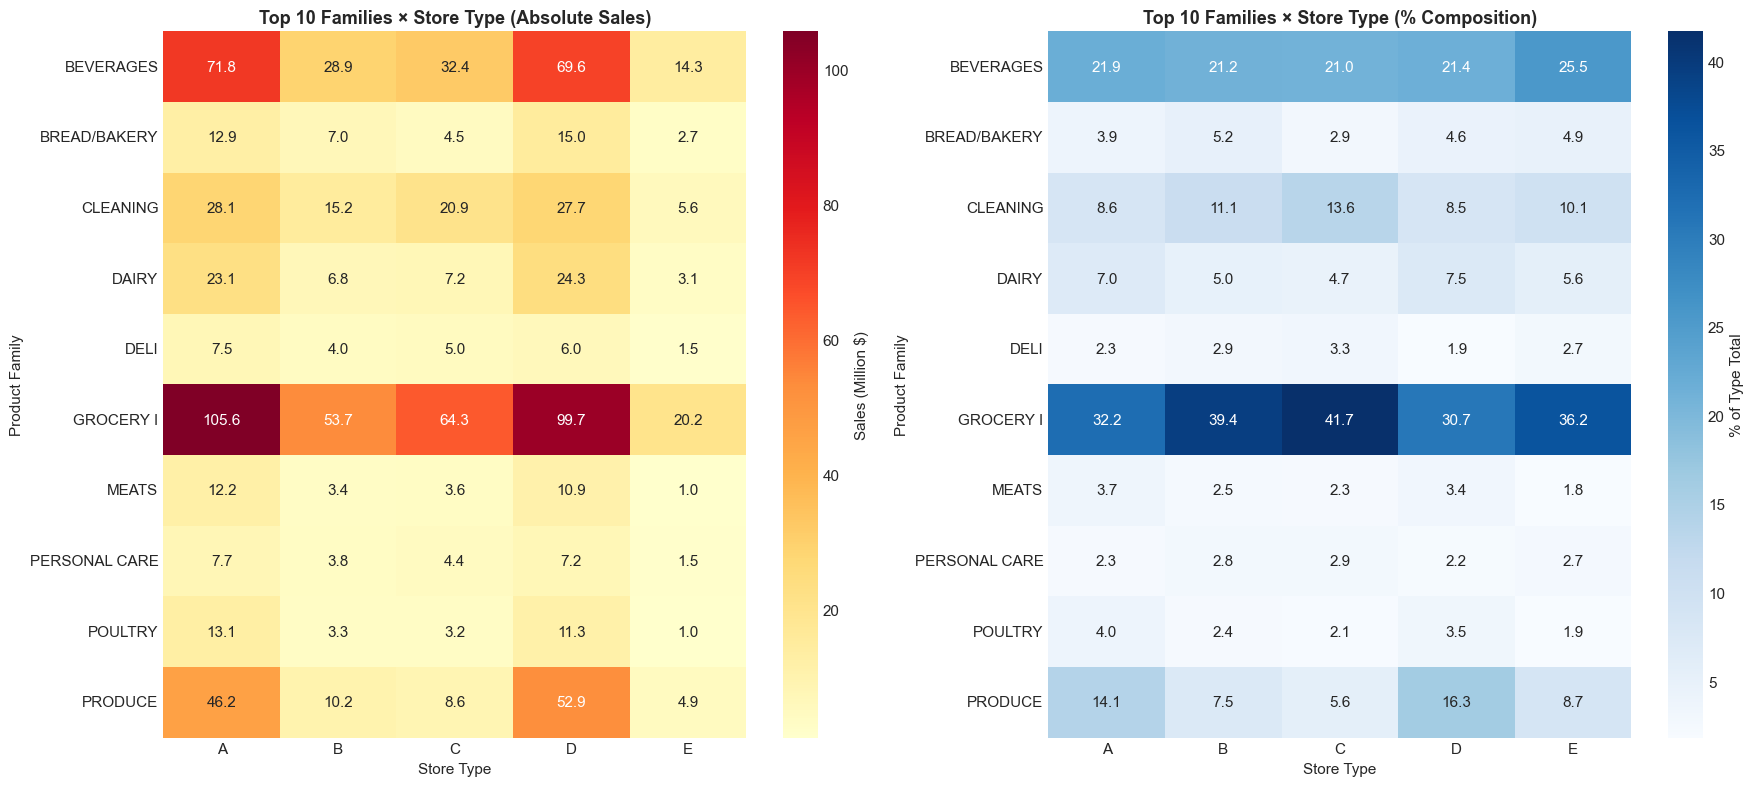

In [13]:
# ==== PRODUCT FAMILY × STORE TYPE ====
family_type = df.groupby(['type', 'family'])['sales'].sum().reset_index()
top_families = df.groupby('family')['sales'].sum().nlargest(10).index

# Filter top families for clarity
family_type_top = family_type[family_type['family'].isin(top_families)]
pivot_ft = family_type_top.pivot_table(index='family', columns='type', values='sales', aggfunc='sum')

# Normalize by type total to see % composition
pivot_ft_pct = pivot_ft.div(pivot_ft.sum(axis=0), axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# (A) Absolute sales heatmap
sns.heatmap(pivot_ft / 1e6, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Sales (Million $)'})
axes[0].set_title('Top 10 Families × Store Type (Absolute Sales)', fontweight='bold')
axes[0].set_ylabel('Product Family')
axes[0].set_xlabel('Store Type')

# (B) Percentage composition heatmap
sns.heatmap(pivot_ft_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            cbar_kws={'label': '% of Type Total'})
axes[1].set_title('Top 10 Families × Store Type (% Composition)', fontweight='bold')
axes[1].set_ylabel('Product Family')
axes[1].set_xlabel('Store Type')

plt.tight_layout()
plt.show()

## 11. Store Predictability Score

Đánh giá stores nào dễ predict hơn dựa trên variance, zero-sales, và consistency.

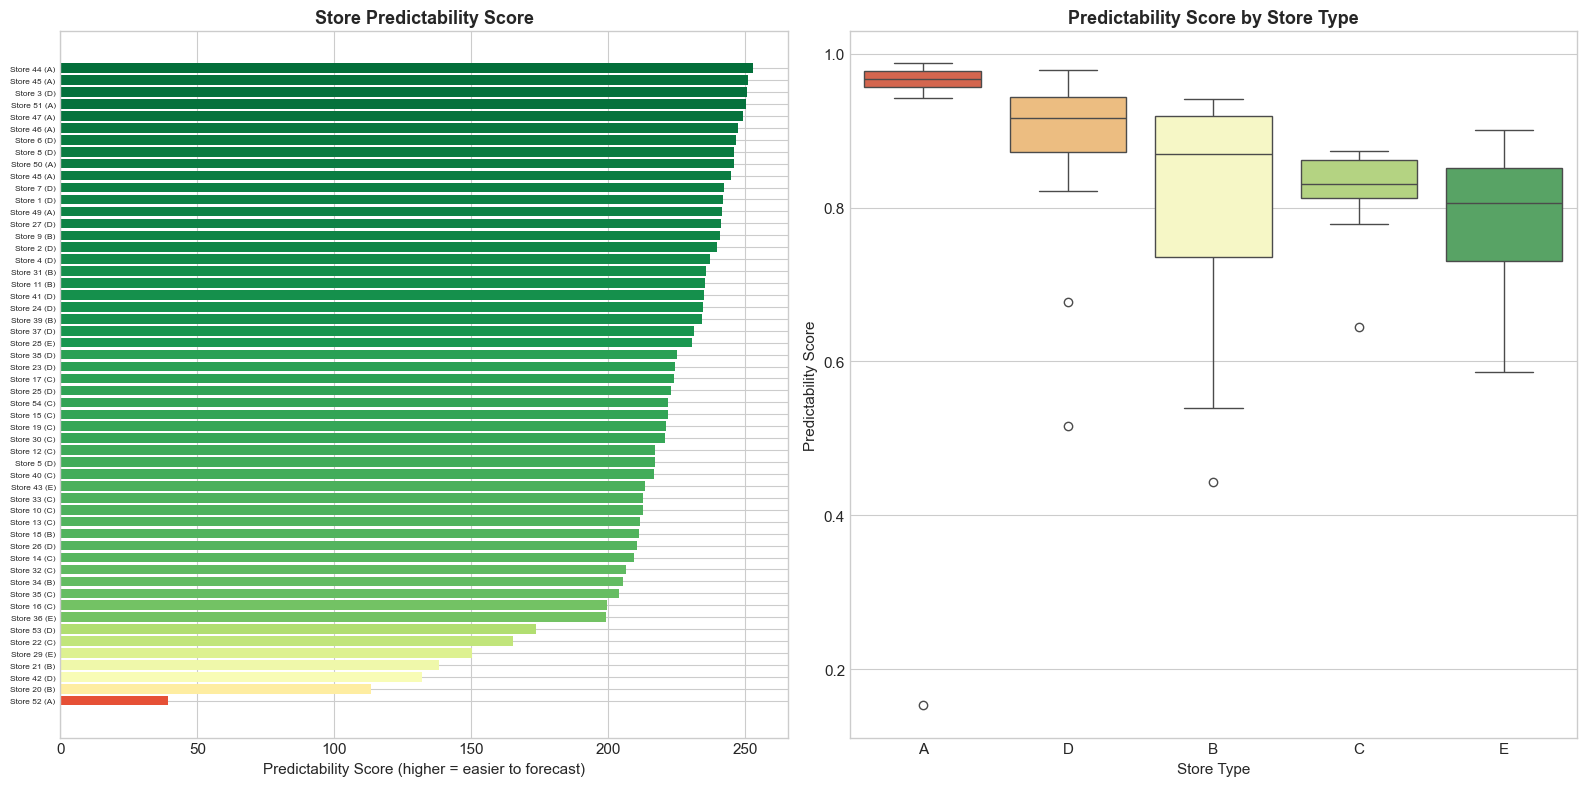

=== Most Predictable Stores ===
  Store 44: Score=0.987 (Quito, Type A, CV=2.40)
  Store 45: Score=0.980 (Quito, Type A, CV=2.43)
  Store 3: Score=0.979 (Quito, Type D, CV=2.36)
  Store 51: Score=0.978 (Guayaquil, Type A, CV=2.28)
  Store 47: Score=0.973 (Quito, Type A, CV=2.42)

=== Least Predictable Stores ===
  Store 52: Score=0.153 (Manta, Type A, CV=9.26)
  Store 20: Score=0.443 (Quito, Type B, CV=4.16)
  Store 42: Score=0.516 (Cuenca, Type D, CV=3.62)
  Store 21: Score=0.540 (Santo Domingo, Type B, CV=3.91)
  Store 29: Score=0.586 (Guayaquil, Type E, CV=3.47)


In [14]:
# ==== PREDICTABILITY SCORE ====
# Higher score = easier to predict
# Components: inverse CV, low zero-sales%, rank stability

# Compute rank stability (was in deleted yearly trajectory cell)
df['year'] = df['date'].dt.year
store_yearly = df.groupby(['store_nbr', 'year'])['sales'].sum().reset_index()
pivot_yearly = store_yearly.pivot_table(index='store_nbr', columns='year', values='sales')
yearly_ranks = pivot_yearly.rank(ascending=False)
rank_std_series = yearly_ranks.std(axis=1)

store_metrics['cv_score'] = 1 - (store_metrics['cv'] - store_metrics['cv'].min()) / (store_metrics['cv'].max() - store_metrics['cv'].min())
store_metrics['zero_score'] = 1 - (store_metrics['zero_sales_pct'] - store_metrics['zero_sales_pct'].min()) / (store_metrics['zero_sales_pct'].max() - store_metrics['zero_sales_pct'].min())

# Add rank stability
store_metrics = store_metrics.merge(
    rank_std_series.reset_index().rename(columns={'index': 'store_nbr', 0: 'rank_std'}),
    on='store_nbr', how='left'
)
store_metrics['stability_score'] = 1 - (store_metrics['rank_std'] - store_metrics['rank_std'].min()) / (store_metrics['rank_std'].max() - store_metrics['rank_std'].min())

# Composite score
store_metrics['predictability'] = (
    0.4 * store_metrics['cv_score'] +
    0.3 * store_metrics['zero_score'] +
    0.3 * store_metrics['stability_score']
)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# (A) Predictability score distribution
pred_sorted = store_metrics.sort_values('predictability', ascending=True)
colors_pred = plt.cm.RdYlGn(pred_sorted['predictability'])
axes[0].barh(
    [f"Store {int(s)} ({t})" for s, t in zip(pred_sorted['store_nbr'], pred_sorted['type'])],
    pred_sorted['predictability'],
    color=colors_pred
)
axes[0].set_xlabel('Predictability Score (higher = easier to forecast)')
axes[0].set_title('Store Predictability Score', fontweight='bold')
axes[0].tick_params(axis='y', labelsize=6)

# (B) Predictability by type
sns.boxplot(data=store_metrics, x='type', y='predictability', ax=axes[1], palette='RdYlGn')
axes[1].set_title('Predictability Score by Store Type', fontweight='bold')
axes[1].set_ylabel('Predictability Score')
axes[1].set_xlabel('Store Type')

plt.tight_layout()
plt.show()

# Print results
print('=== Most Predictable Stores ===')
for _, row in store_metrics.nlargest(5, 'predictability').iterrows():
    print(f"  Store {int(row['store_nbr'])}: Score={row['predictability']:.3f} "
          f"({row['city']}, Type {row['type']}, CV={row['cv']:.2f})")

print('\n=== Least Predictable Stores ===')
for _, row in store_metrics.nsmallest(5, 'predictability').iterrows():
    print(f"  Store {int(row['store_nbr'])}: Score={row['predictability']:.3f} "
          f"({row['city']}, Type {row['type']}, CV={row['cv']:.2f})")
